In [1]:
import pandas as pd
from sklearn.mixture import GaussianMixture
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import numpy as np
from hmmlearn.hmm import GaussianHMM
import hdbscan
import plotly.graph_objects as go



regime_gap = bull_short - bull_long


gap > 0.2 → strong bullish acceleration

gap < -0.2 → strong bearish acceleration

In [2]:
with open('../../data/nifty_ts2vec_embeddings.pkl', 'rb') as f:
    df = pickle.load(f)

In [3]:
df = df.loc["2020-04-01":]

In [4]:
embeddings = df.drop("Close", axis=1)
embeddings

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
Date,,,,,,,,,,,,,,,,,,,,,
2020-04-01,0.024996,0.000573,0.056949,0.0,0.023999,0.000000,0.000000,0.000000,0.000000,0.003505,...,0.010201,0.000000,0.037527,0.000000,0.048713,0.005605,0.009870,0.079661,0.000000,0.000000
2020-04-03,0.025383,0.000573,0.051881,0.0,0.017305,0.000000,0.000000,0.000000,0.000000,0.004882,...,0.013386,0.000000,0.041550,0.000000,0.048225,0.004729,0.008182,0.073353,0.000000,0.000000
2020-04-07,0.025566,0.000573,0.045521,0.0,0.011762,0.000000,0.000000,0.000000,0.000000,0.007103,...,0.014810,0.000000,0.046889,0.000000,0.048225,0.002819,0.006701,0.065087,0.000000,0.000000
2020-04-08,0.023787,0.000573,0.038235,0.0,0.007074,0.000000,0.000000,0.000000,0.000000,0.011992,...,0.016546,0.000000,0.053869,0.000000,0.048225,0.000940,0.004076,0.055605,0.000000,0.000000
2020-04-09,0.020833,0.000573,0.030917,0.0,0.003354,0.000000,0.000000,0.000000,0.000000,0.018106,...,0.017318,0.000000,0.062545,0.000000,0.048225,0.000000,0.002469,0.047682,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-15,0.030476,0.000000,0.000000,0.0,0.002600,0.108412,0.022924,0.023285,0.022413,0.039453,...,0.054028,0.052031,0.000000,0.030598,0.124933,0.000000,0.006461,0.000000,0.001989,0.045353
2025-09-16,0.019075,0.000006,0.000000,0.0,0.002174,0.097264,0.031640,0.022386,0.024088,0.042421,...,0.049431,0.040375,0.000000,0.028497,0.123058,0.000000,0.009521,0.000000,0.002680,0.046061
2025-09-17,0.010408,0.002368,0.000000,0.0,0.001160,0.083648,0.037119,0.020733,0.024845,0.044540,...,0.046623,0.029450,0.000000,0.025117,0.119865,0.000000,0.011029,0.000000,0.003482,0.048270


In [5]:
30*0.6

18.0

In [6]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=6,
    metric="euclidean",
    cluster_selection_method="leaf",
    cluster_selection_epsilon = 0,   
    allow_single_cluster=False,
    prediction_data=True
)
labels = clusterer.fit_predict(embeddings)

In [7]:
df["HDBSCAN_Labels"] = labels

In [8]:
df["HDBSCAN_Labels"].value_counts(normalize=True)

HDBSCAN_Labels
-1     0.246677
 12    0.056869
 1     0.045052
 5     0.043575
 6     0.042836
 16    0.040620
 8     0.036189
 4     0.035451
 14    0.034712
 18    0.032496
 21    0.031758
 7     0.031019
 20    0.026588
 19    0.025849
 0     0.025849
 22    0.024372
 11    0.023634
 9     0.023634
 17    0.023634
 10    0.022895
 13    0.022157
 24    0.022157
 2     0.021418
 3     0.020679
 15    0.019941
 23    0.019941
Name: proportion, dtype: float64

In [9]:
df["HDBSCAN_Labels"].value_counts(normalize=True).head().to_clipboard()

In [10]:
df["HDBSCAN_Labels"].nunique() #51

26

In [11]:
fig = go.Figure()

# Scatter per regime/cluster
for c in sorted(df["HDBSCAN_Labels"].dropna().unique()):
    mask = df["HDBSCAN_Labels"] == c
    fig.add_trace(
        go.Scatter(
            x=df.index[mask],
            y=df.loc[mask, "Close"],
            mode="markers",
            name=f"Regime {c}",
            marker=dict(size=6),
        )
    )

# Underlay full close series
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
    )
)

fig.update_layout(
    title="Nifty 50 Regimes (Clustering)",
    # width=1400,
    height=820,
    legend_title_text="Regime",
    xaxis_title="Date",
    yaxis_title="Close",
    template="plotly_white",
)

fig.show()

In [13]:
# plt.figure(figsize=(25,6))

# for c in df['HDBSCAN_Labels'].dropna().unique():
#     mask = df['HDBSCAN_Labels'] == c
#     plt.scatter(df.index[mask], df['Close'][mask], label=f"Regime {c}", s=10)
# plt.plot(df.index, df['Close'], color='black', linewidth=0.5, alpha=0.6)
# plt.title("Nifty 50 Regimes (Clustering)")
# plt.legend()
# plt.show()

In [12]:
hdb_labels = df["HDBSCAN_Labels"].values

In [13]:
from sklearn.metrics import pairwise_distances_argmin

# Ensure we operate on numpy arrays (pairwise_distances_argmin expects array-like)
X = embeddings.to_numpy() if hasattr(embeddings, "to_numpy") else np.asarray(embeddings)
labels = np.asarray(hdb_labels).copy()

# centroids from non-noise clusters
clusters = np.unique(labels[labels >= 0])

# If everything is noise (or there are no points), we can't reassign
if clusters.size == 0:
    print("No non-noise clusters found; leaving labels unchanged.")
else:
    centroids = np.vstack([X[labels == k].mean(axis=0) for k in clusters])

    # reassign noise (if any) to nearest centroid
    noise_idx = np.where(labels == -1)[0]
    if noise_idx.size == 0:
        print("No noise points to reassign.")
    else:
        nearest = pairwise_distances_argmin(X[noise_idx], centroids)
        labels[noise_idx] = clusters[nearest]

In [14]:
np.mean(labels == -1)

0.0

In [15]:
len(centroids)

25

In [16]:
from sklearn.cluster import AgglomerativeClustering

K0 = 15  # start here

agg = AgglomerativeClustering(
    n_clusters=K0,
    linkage="ward"
)

proto_labels = agg.fit_predict(centroids)

In [17]:
proto_labels

array([10,  4,  4, 14,  6,  2,  2,  2, 11, 13,  9,  8,  8,  5,  3,  3,  5,
       12,  1,  1,  0,  0,  6,  7,  7])

In [18]:
proto_state = np.zeros_like(labels)
cluster_ids = np.unique(labels)

for cid, p in zip(cluster_ids, proto_labels):
    proto_state[labels == cid] = p

In [19]:
np.unique(proto_state)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [20]:
def init_from_micro_regimes(X, labels, min_points=20):
    states = np.unique(labels)
    means, covs = [], []

    for k in states:
        pts = X[labels == k]
        if len(pts) < min_points:
            continue
        means.append(pts.mean(axis=0))
        covs.append(
            np.cov(pts.T) + 1e-6 * np.eye(X.shape[1])
        )

    return np.array(means), np.array(covs)


def full_to_diag_cov(covs):
    """
    covs: (K, D, D)
    returns: (K, D)
    """
    return np.array([
        np.diag(cov) for cov in covs
    ])


def init_from_proto_states_diag(X, proto_state, min_points=50):
    states = np.unique(proto_state)
    means, diag_covs = [], []

    for k in states:
        pts = X[proto_state == k]
        if len(pts) < min_points:
            continue

        mu = pts.mean(axis=0)
        cov = np.cov(pts.T)

        # strong regularization for stability
        cov += 1e-3 * np.eye(X.shape[1])

        means.append(mu)
        diag_covs.append(np.diag(cov))

    return np.array(means), np.array(diag_covs)

In [21]:
init_means, init_covs = init_from_proto_states_diag(
    embeddings, proto_state
)

K = len(init_means)
print("HMM init states:", K)

HMM init states: 11


In [22]:
from hmmlearn.hmm import GaussianHMM

def sticky_transition(K, kappa=70, base=1.0):
    A = np.full((K, K), base)
    np.fill_diagonal(A, base + kappa)
    return A / A.sum(axis=1, keepdims=True)


model = GaussianHMM(
    n_components=K,
    covariance_type="diag",   
    n_iter=1500,
    tol=1e-3,
    init_params=""
)

model.startprob_ = np.ones(K) / K
model.transmat_ = sticky_transition(K)
model.means_ = init_means
model.covars_ = init_covs

model.fit(embeddings)

Model is not converging.  Current: 479033.8075489217 is not greater than 479033.9833693433. Delta is -0.1758204216021113


,n_components,11
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,None


In [23]:
# save the model
with open('../../models/nifty_hmm_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [5]:
# load the model
with open('../../models/nifty_hmm_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [24]:
post = model.predict_proba(embeddings)
state_mass = post.mean(axis=0)

print("Effective states:",
      np.sum(state_mass > 0.01))

Effective states: 11


In [25]:
post.shape

(1354, 11)

In [26]:
len(state_mass)

11

In [27]:
state_mass

array([0.07641755, 0.08713953, 0.12704651, 0.07178627, 0.12004993,
       0.08792688, 0.08492296, 0.0709294 , 0.13733386, 0.05460394,
       0.08184317])

In [28]:
keep = state_mass > 0.03
posteriors = post[:, keep]

In [29]:
posteriors.shape

(1354, 11)

In [30]:
viterbi = model.predict(embeddings)
np.mean(viterbi[1:] == viterbi[:-1])

0.9881744271988174

In [31]:
len(viterbi)

1354

In [32]:
df["HMM_Labels"] = viterbi

In [33]:
df["HMM_Labels"].value_counts()

HMM_Labels
8     186
2     172
4     163
5     119
1     118
6     115
10    111
0     103
3      97
7      96
9      74
Name: count, dtype: int64

In [34]:
fig = go.Figure()

# Scatter per regime/cluster
for c in sorted(df["HMM_Labels"].dropna().unique()):
    mask = df["HMM_Labels"] == c
    fig.add_trace(
        go.Scatter(
            x=df.index[mask],
            y=df.loc[mask, "Close"],
            mode="markers",
            name=f"Regime {c}",
            marker=dict(size=6),
        )
    )

# Underlay full close series
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
    )
)

fig.update_layout(
    title="Nifty 50 Regimes (Clustering)",
    # width=1400,
    height=820,
    legend_title_text="Regime",
    xaxis_title="Date",
    yaxis_title="Close",
    template="plotly_white",
)

fig.show()

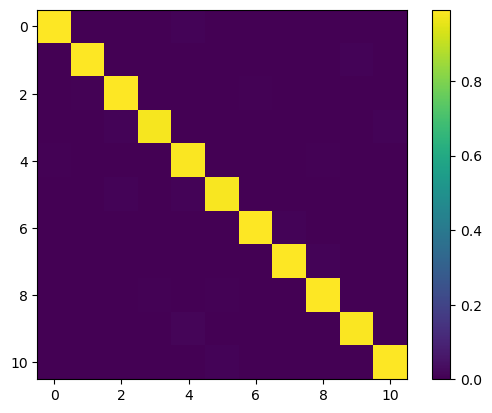

In [35]:
plt.imshow(model.transmat_, cmap="viridis")
plt.colorbar()

In [36]:
def compute_state_signatures(
    states,
    returns,
    volatility,
    price,
    lookback_weight=None
):
    """
    returns DataFrame of shape (K, features)
    """

    K = int(states.max()) + 1
    sig = []
    print("Computing signatures for", K, "states")

    T = len(states)
    weights = (
        np.exp(-np.arange(T)[::-1] / lookback_weight)
        if lookback_weight is not None
        else np.ones(T)
    )

    for k in range(K):
        print(f"State {k}: ", end="")
        idx = states == k
        if idx.sum() < 30:
            print("Ignoring ", idx)
            continue

        w = weights[idx]

        sig.append({
            "state": k,
            "freq": idx.mean(),
            "mean_return": np.average(returns[idx], weights=w),
            "volatility": np.average(volatility[idx], weights=w),
            "trend": np.polyfit(
                np.arange(idx.sum()),
                price[idx],
                1
            )[0],
            "drawdown": np.min(
                price[idx] / np.maximum.accumulate(price[idx]) - 1
            ),
        })

    return pd.DataFrame(sig).set_index("state")

In [37]:
# X_emb        # ts2vec embeddings (T, D)
# returns      # daily log returns (T,)
# volatility   # rolling vol (T,)
# price        # index price (T,)
# states       # HMM state sequence (T,)
# posteriors   # HMM posteriors (T, K)

returns = np.log(df["Close"] / df["Close"].shift(1)).fillna(0).values
volatility = df["Close"].rolling(20).std().bfill().values
price = df["Close"].values
states = viterbi
state_df = compute_state_signatures(
    states, returns, volatility, price, lookback_weight=100
)


Computing signatures for 11 states
State 0: State 1: State 2: State 3: State 4: State 5: State 6: State 7: State 8: State 9: State 10: 

In [38]:

state_df.sort_values("freq", ascending=False)

,freq,mean_return,volatility,trend,drawdown
state,,,,,
8,0.137371,0.001049,281.555123,22.363237,-0.066119
2,0.127031,-0.001758,393.220310,46.324295,-0.121134
4,0.120384,0.000206,254.736228,55.515137,-0.080072
5,0.087888,-0.000117,389.837220,55.532061,-0.133545
1,0.087149,0.000896,321.267628,20.411532,-0.080256
6,0.084934,0.000993,284.511165,24.192683,-0.068974
10,0.081979,0.000011,362.394511,1.799180,-0.109328
0,0.076071,0.000574,314.278066,16.722547,-0.063673
3,0.071640,0.000996,255.631390,86.604355,-0.059294


In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

features = [
    "mean_return",
    "volatility",
    "trend",
    "drawdown",
]

X_state = StandardScaler().fit_transform(state_df[features])

clusterer = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

state_df["macro_regime"] = clusterer.fit_predict(X_state)

In [40]:
state_to_macro = state_df["macro_regime"].to_dict()
macro_states = np.array([state_to_macro[s] for s in states])

In [41]:
macro_summary = (
    state_df
    .groupby("macro_regime")
    .agg({
        "mean_return": "mean",
        "volatility": "mean",
        "trend": "mean",
        "drawdown": "mean",
    })
)

In [42]:
labels = {}

ret_rank = macro_summary["mean_return"].rank()
vol_rank = macro_summary["volatility"].rank()
dd_rank  = macro_summary["drawdown"].rank()

for k in macro_summary.index:
    if ret_rank[k] == ret_rank.max() and vol_rank[k] <= 3:
        labels[k] = "Strong Bull"

    elif ret_rank[k] >= 4:
        labels[k] = "Bull"

    elif ret_rank[k] <= 2 and dd_rank[k] <= 2:
        labels[k] = "Bear"

    elif vol_rank[k] == vol_rank.max():
        labels[k] = "High Volatility"

    else:
        labels[k] = "Sideways / Transition"

In [43]:
macro_summary["label"] = macro_summary.index.map(labels)

In [44]:
macro_summary

,mean_return,volatility,trend,drawdown,label
macro_regime,,,,,
0,0.000704,312.801298,17.097836,-0.077670,Bull
1,-0.000938,391.528765,50.928178,-0.127339,Bear
2,0.000601,255.183809,71.059746,-0.069683,Sideways / Transition
3,0.002095,197.387677,23.648445,-0.026747,Strong Bull
4,-0.000382,187.710000,-15.297547,-0.080189,Bear


In [45]:
bull_strength = {}

for k, row in macro_summary.iterrows():
    if row["label"] == "Strong Bull":
        bull_strength[k] = 1.0
    elif row["label"] == "Bull":
        bull_strength[k] = 0.75
    elif row["label"] == "Sideways / Transition":
        bull_strength[k] = 0.55
    elif row["label"] == "High Volatility":
        bull_strength[k] = 0.2
    else:  # Bear
        bull_strength[k] = 0.0

In [46]:
def rolling_percentile(x, window=252):
    out = np.full_like(x, np.nan)
    for i in range(window, len(x)):
        out[i] = (
            np.sum(x[i-window:i] <= x[i]) / window
        )
    return out

In [47]:
state_to_macro

{0: 0, 1: 0, 2: 1, 3: 2, 4: 2, 5: 1, 6: 0, 7: 3, 8: 0, 9: 4, 10: 0}

In [48]:
state_bull_strength = {
    s: bull_strength[state_to_macro[s]]
    for s in state_to_macro
}
state_bull_strength

{0: 0.75,
 1: 0.75,
 2: 0.0,
 3: 0.55,
 4: 0.55,
 5: 0.0,
 6: 0.75,
 7: 1.0,
 8: 0.75,
 9: 0.0,
 10: 0.75}

In [49]:
def bull_confidence_from_posteriors(posteriors, state_bull_strength):
    """
    posteriors: (T, K)
    returns: (T,) bull confidence in [0, 1]
    """
    weights = np.array([
        state_bull_strength[k] for k in range(posteriors.shape[1])
    ])
    return posteriors @ weights

In [50]:
posteriors

array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       ...,
       [3.96119405e-045, 0.00000000e+000, 0.00000000e+000, ...,
        9.64088858e-209, 0.00000000e+000, 0.00000000e+000],
       [1.67086221e-046, 0.00000000e+000, 0.00000000e+000, ...,
        1.74129930e-193, 0.00000000e+000, 0.00000000e+000],
       [3.26739756e-046, 0.00000000e+000, 0.00000000e+000, ...,
        1.54955680e-098, 0.00000000e+000, 0.00000000e+000]])

In [51]:
bull_conf = bull_confidence_from_posteriors(
    posteriors,
    state_bull_strength
)
bull_conf

array([0.55, 0.55, 0.55, ..., 0.55, 0.55, 0.55])

In [52]:
# plot bull confidence over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf,
        mode="lines",
        name="Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Confidence Over Time",
    xaxis_title="Date",
    yaxis_title="Bull Confidence",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [53]:
def smooth_series(x, half_life=20):
    alpha = 1 - np.exp(np.log(0.5) / half_life)
    y = np.zeros_like(x)
    y[0] = x[0]
    for t in range(1, len(x)):
        y[t] = alpha * x[t] + (1 - alpha) * y[t-1]
    return y

bull_conf_smooth = smooth_series(bull_conf, half_life=20)
bull_conf_rel = rolling_percentile(bull_conf_smooth, 252)

In [54]:
# plot bull_conf_smooth over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf_smooth,
        mode="lines",
        name="Smoothed Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf_rel,
        mode="lines",
        name="Relative Bull Confidence",
        line=dict(color="green", width=2, dash="dash"),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Smoothed Bull Confidence Over Time",
    xaxis_title="Date",
    yaxis_title="Smoothed Bull Confidence",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [55]:
bull_momentum = bull_conf_smooth - smooth_series(
    bull_conf_smooth, half_life=60
)

In [56]:
# plot bull momentum over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_momentum,
        mode="lines",
        name="Bull Momentum",
        line=dict(color="red", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Momentum Over Time",
    xaxis_title="Date",
    yaxis_title="Bull Momentum",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [57]:
from scipy.stats import multivariate_normal

def hmm_filter_step(x_t, prev_gamma, model):
    K = model.n_components

    # emission likelihoods
    lik = np.zeros(K)
    for k in range(K):
        lik[k] = multivariate_normal.pdf(
            x_t,
            mean=model.means_[k],
            cov=model.covars_[k]
        )

    # predict
    pred = prev_gamma @ model.transmat_

    # update
    gamma = pred * lik
    gamma /= gamma.sum()

    return gamma

In [58]:
gamma_t = posteriors[-1]
gamma_t

array([3.26739756e-046, 0.00000000e+000, 0.00000000e+000, 1.60890066e-216,
       1.00000000e+000, 2.23160335e-207, 0.00000000e+000, 0.00000000e+000,
       1.54955680e-098, 0.00000000e+000, 0.00000000e+000])

In [59]:
# infer_ts2vec_embeddings
with open('../../data/infer_ts2vec_embeddings.pkl', 'rb') as f:
    infer_embeddings = pickle.load(f)

In [60]:
i_close = infer_embeddings["Close"]
infer_emb = infer_embeddings.drop("Close", axis=1).values
infer_emb

array([[2.43657697e-02, 1.66791398e-02, 1.44605967e-03, ...,
        0.00000000e+00, 8.95652513e-04, 5.47044426e-02],
       [3.21266502e-02, 1.82007048e-02, 6.20688777e-03, ...,
        0.00000000e+00, 2.04119351e-04, 5.20410314e-02],
       [3.60560045e-02, 1.78403966e-02, 1.16548454e-02, ...,
        0.00000000e+00, 0.00000000e+00, 4.69038561e-02],
       ...,
       [1.19992584e-01, 0.00000000e+00, 0.00000000e+00, ...,
        1.73095934e-04, 0.00000000e+00, 1.93517387e-01],
       [1.16978072e-01, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.88467920e-01],
       [1.13594726e-01, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.87530965e-01]], dtype=float32)

In [61]:
infer_embeddings

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,Close
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-22,0.024366,0.016679,0.001446,0.0,0.000296,0.045045,0.042060,0.015169,0.018079,0.060219,...,0.019970,0.000000,0.015816,0.118297,0.0,0.009491,0.000000,0.000896,0.054704,25202.349609
2025-09-23,0.032127,0.018201,0.006207,0.0,0.000193,0.036059,0.044192,0.015491,0.015427,0.065883,...,0.022658,0.000000,0.013822,0.119071,0.0,0.008521,0.000000,0.000204,0.052041,25169.500000
2025-09-24,0.036056,0.017840,0.011655,0.0,0.000000,0.031033,0.047209,0.015292,0.013869,0.070268,...,0.026075,0.000000,0.011653,0.119840,0.0,0.007423,0.000000,0.000000,0.046904,25056.900391
2025-09-25,0.036470,0.018000,0.017973,0.0,0.000386,0.029524,0.050833,0.014964,0.011014,0.071080,...,0.028563,0.000000,0.010547,0.118944,0.0,0.005023,0.000000,0.000000,0.039292,24890.849609
2025-09-26,0.035231,0.018345,0.021695,0.0,0.000399,0.026336,0.053617,0.016982,0.008276,0.071641,...,0.031045,0.000000,0.010178,0.117865,0.0,0.002377,0.000000,0.000000,0.033579,24654.699219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,0.122133,0.000000,0.002236,0.0,0.065892,0.025297,0.037269,0.012507,0.000000,0.051424,...,0.000000,0.017649,0.000000,0.000000,0.0,0.002284,0.000146,0.000000,0.217994,25471.099609
2026-02-16,0.120922,0.000000,0.000390,0.0,0.061576,0.020006,0.037269,0.015455,0.000000,0.052388,...,0.000000,0.017775,0.000000,0.000000,0.0,0.001310,0.001001,0.000000,0.204451,25682.750000
2026-02-17,0.119993,0.000000,0.000000,0.0,0.058461,0.015654,0.038269,0.020194,0.000000,0.052054,...,0.000000,0.016447,0.000000,0.000000,0.0,0.003356,0.000173,0.000000,0.193517,25725.400391


In [62]:
i_close

Date
2025-09-22    25202.349609
2025-09-23    25169.500000
2025-09-24    25056.900391
2025-09-25    24890.849609
2025-09-26    24654.699219
                  ...     
2026-02-13    25471.099609
2026-02-16    25682.750000
2026-02-17    25725.400391
2026-02-18    25819.349609
2026-02-19    25454.349609
Name: Close, Length: 103, dtype: float64

In [63]:
gamma_t = posteriors[-1]

bull_conf_live = []

for x_t in infer_emb:   # streaming TS2Vec embeddings
    gamma_t = hmm_filter_step(x_t, gamma_t, model)

    bc = sum(
        gamma_t[k] * state_bull_strength[k]
        for k in range(len(gamma_t))
    )
    bull_conf_live.append(bc)

In [64]:
# merge old bull confidence with new
full_bull_conf = np.concatenate([bull_conf, bull_conf_live])

In [65]:
bull_conf_live_smooth = smooth_series(
    np.array(full_bull_conf),
    half_life=20
)
bull_conf_live_rel = rolling_percentile(bull_conf_live_smooth, 252)

In [66]:
bull_momentum_live = bull_conf_live_smooth - smooth_series(
    bull_conf_live_smooth, half_life=60
)

In [67]:
len(bull_conf_live_rel)

1457

In [68]:
# bull_momentum, bull_conf_smooth, df["Close"]

cdf=pd.DataFrame({
    "bull_momentum": bull_momentum_live,
    "bull_confidence": bull_conf_live_smooth,
    "bull_confidence_rel": bull_conf_live_rel,
    "close":  df["Close"].tolist() + i_close.tolist()
})
cdf.index = df.index.tolist() + infer_embeddings.index.tolist()

In [69]:
cdf

,bull_momentum,bull_confidence,bull_confidence_rel,close
2020-04-01,0.000000,0.550000,NaN,8253.799805
2020-04-03,0.000000,0.550000,NaN,8083.799805
2020-04-07,0.000000,0.550000,NaN,8792.200195
2020-04-08,0.000000,0.550000,NaN,8748.750000
2020-04-09,0.000000,0.550000,NaN,9111.900391
...,...,...,...,...
2026-02-13,0.067991,0.707960,0.765873,25471.099609
2026-02-16,0.068625,0.709392,0.769841,25682.750000
2026-02-17,0.069205,0.710776,0.773810,25725.400391
2026-02-18,0.069730,0.712112,0.777778,25819.349609


In [71]:
# plot bull_momentum and bull_confidence and close over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=cdf.index,
        y=cdf["bull_momentum"],
        mode="lines",
        name="Bull Momentum",
        line=dict(color="red", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=cdf.index,
        y=cdf["bull_confidence"],
        mode="lines",
        name="Smoothed Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=cdf.index,
        y=cdf["bull_confidence_rel"],
        mode="lines",
        name="Relative Bull Confidence",
        line=dict(color="green", width=2, dash="dash"),
    )
)
fig.add_trace(
    go.Scatter(
        x=cdf.index,
        y=cdf["close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Momentum and Confidence (Live Inference)",
    xaxis_title="Date",
    yaxis_title="Value",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()